# **K-Nearest Neighbors Regressor**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
    r2_score, mean_absolute_error, mean_squared_error
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
%matplotlib inline

## **1. Create the Regression Dataset**

A Regression dataset with 1000 samples and 2 features, using `make_regression`.

In [2]:
# Import the function to generate a synthetic regression dataset
from sklearn.datasets import make_regression

# Import the function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Create a synthetic regression dataset
X_r, y_r = make_regression(
    n_samples=1000,      # Total number of samples
    n_features=2,        # Number of input features
    noise=15,            # Add random noise to make the dataset more realistic
    random_state=15      # Ensures reproducible results
)

# Split the dataset into training and testing sets
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_r,
    y_r,
    test_size=0.25,      # 25% of the data is used for testing
    random_state=15      # Ensures the same split every time
)

# Display the shape of the training feature matrix
print("Xr_train shape:", Xr_train.shape)

# Display the shape of the testing feature matrix
print("Xr_test shape :", Xr_test.shape)

Xr_train shape: (750, 2)
Xr_test shape : (250, 2)


# **2. Train the K-Nearest Neighbors (KNN) Regressor**

In this section, we use the **K-Nearest Neighbors Regressor (KNeighborsRegressor)** to predict **continuous numerical values**.

Unlike **KNeighborsClassifier**, which predicts a class label using **majority voting**, **KNeighborsRegressor** predicts a numerical value by taking the **average (or weighted average)** of the target values of the nearest neighbors.

---

### **Creating the KNN Regressor**

The model is created using:

```python
KNeighborsRegressor(n_neighbors=6, algorithm='auto')
```

### **Parameter Explanation**

| Parameter | Value | Description |
|-----------|------:|-------------|
| `n_neighbors` | 6 | Uses the 6 nearest neighbors to make each prediction. |
| `algorithm` | `'auto'` | Scikit-learn automatically selects the most efficient nearest-neighbor search algorithm. |

---

### **Training the Model**

During training, the KNN Regressor does **not** learn coefficients or build a mathematical equation.

Instead, it stores the training data and uses it during prediction.

This is why KNN is called a **Lazy Learning Algorithm**.

---

### **Making Predictions**


For each test sample, the algorithm:

1. Computes the distance to every training sample.
2. Finds the **6 nearest neighbors**.
3. Retrieves their target values.
4. Computes the **average** of those target values.
5. Returns the average as the predicted value.

For example:

| Neighbor | Target Value |
|----------|-------------:|
| 1 | 120 |
| 2 | 125 |
| 3 | 118 |
| 4 | 122 |
| 5 | 121 |
| 6 | 124 |

Predicted value:

```text
(120 + 125 + 118 + 122 + 121 + 124) / 6
= 121.67
```
---

### **Interpretation**

When evaluating a KNN Regressor:

- **Higher R² Score** → Better model fit.
- **Lower MAE** → Smaller average prediction error.
- **Lower MSE** → Fewer large prediction errors.

Together, these metrics provide a comprehensive view of how accurately the model predicts continuous values.




In [3]:
# Import the K-Nearest Neighbors Regressor
from sklearn.neighbors import KNeighborsRegressor

# Import regression evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Create a KNN Regressor
knn_reg = KNeighborsRegressor(
    n_neighbors=6,      # Use the 6 nearest neighbors
    algorithm='auto'    # Automatically select the most efficient search algorithm
)

# Train the regression model
knn_reg.fit(Xr_train, yr_train)

# Predict the target values for the test dataset
yr_pred = knn_reg.predict(Xr_test)

# Calculate the R² Score
r2 = r2_score(yr_test, yr_pred)

# Calculate the Mean Absolute Error (MAE)
mae = mean_absolute_error(yr_test, yr_pred)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(yr_test, yr_pred)

# Display the evaluation metrics
print(f"R2 Score : {r2:.3f}")
print(f"MAE      : {mae:.3f}")
print(f"MSE      : {mse:.3f}")

R2 Score : 0.951
MAE      : 15.819
MSE      : 426.196


## **3. Actual vs Predicted Plot**

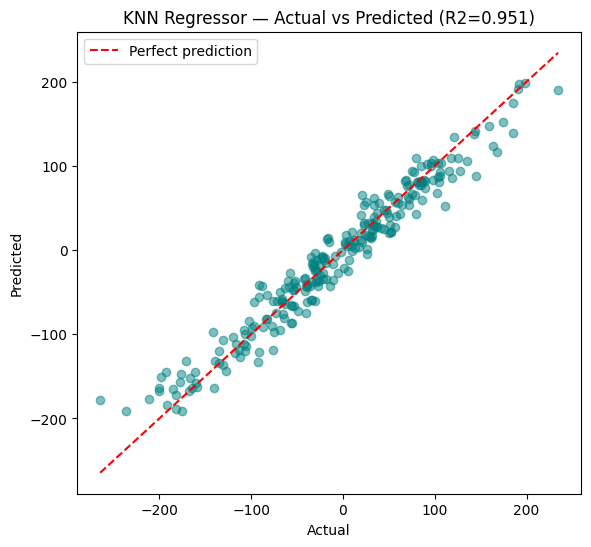

In [6]:
plt.figure(figsize=(6.5, 6))
plt.scatter(yr_test, yr_pred, alpha=0.5, color='teal')
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'KNN Regressor — Actual vs Predicted (R2={r2:.3f})')
plt.legend()
plt.show()

# **4. Try Different `k` Values**

In [4]:
# Create a range of k values to evaluate
# Here, we test k values from 1 to 30
k_range_r = range(1, 31)

# Create an empty list to store the R² Score for each k value
r2_scores = []

# Train and evaluate a KNN Regressor for each value of k
for k in k_range_r:

    # Create a KNN Regressor with the current k value
    model = KNeighborsRegressor(
        n_neighbors=k,
        algorithm='auto'
    )

    # Train the model
    model.fit(Xr_train, yr_train)

    # Predict the target values for the test dataset
    yr_pred = model.predict(Xr_test)

    # Calculate and store the R² Score
    r2_scores.append(r2_score(yr_test, yr_pred))

# Find the value of k that gives the highest R² Score
best_k_r = k_range_r[np.argmax(r2_scores)]

# Display the best k value and its corresponding R² Score
print(f"Best k: {best_k_r}  (R2 = {max(r2_scores):.3f})")

Best k: 4  (R2 = 0.951)


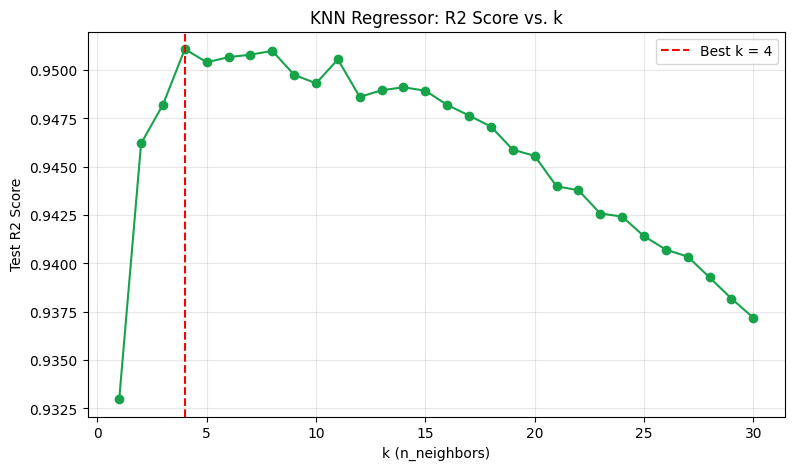

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range_r), r2_scores, marker='o', color='#16a34a')
plt.axvline(best_k_r, color='red', linestyle='--', label=f'Best k = {best_k_r}')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Test R2 Score')
plt.title('KNN Regressor: R2 Score vs. k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **5. GridSearchCV for the Regressor**

In [6]:
# Define the hyperparameter search space
param_grid_r = {

    # Try different values of k (number of neighbors)
    'n_neighbors': list(range(1, 21)),

    # Compare equal voting and distance-based weighting
    'weights': ['uniform', 'distance'],

    # Compare Manhattan (p=1) and Euclidean (p=2) distance metrics
    'p': [1, 2]
}

# Create a GridSearchCV object
grid_r = GridSearchCV(

    # Base regression model
    estimator=KNeighborsRegressor(algorithm='auto'),

    # Hyperparameter combinations to evaluate
    param_grid=param_grid_r,

    # Perform 5-Fold Cross Validation
    cv=5,

    # Optimize using the R² Score
    scoring='r2',

    # Use all available CPU cores
    n_jobs=-1
)

# Train GridSearchCV
# Every parameter combination is evaluated using 5-fold cross validation
grid_r.fit(Xr_train, yr_train)

# Display the best hyperparameter combination
print("Best Parameters:", grid_r.best_params_)

# Display the highest average cross-validation R² Score
print("Best CV R2: {:.3f}".format(grid_r.best_score_))

# Evaluate the best model on the unseen test dataset
print("Test R2 with tuned model: {:.3f}".format(
    grid_r.score(Xr_test, yr_test)
))

Best Parameters: {'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
Best CV R2: 0.961
Test R2 with tuned model: 0.953


# **Note - Why Feature Scaling Matters for KNN**

Just like SVM/SVR, KNN is a **purely distance-based algorithm** — so features on very different scales can silently dominate the distance calculation. Our synthetic datasets above happen to already have comparably-scaled features (which is why scaling didn't come up naturally) — but let's demonstrate the effect directly by artificially stretching one feature, the way a real "income vs age"-style feature mismatch would look.

In [7]:
# Artificially create a scale mismatch: feature 1 in the hundreds, feature 2 tiny
X_mismatched = X_r.copy()
X_mismatched[:, 0] *= 500  # blow up feature 1's scale

X_mm_train, X_mm_test, y_mm_train, y_mm_test = train_test_split(
    X_mismatched, y_r, test_size=0.25, random_state=15
)

# Without scaling
knn_unscaled = KNeighborsRegressor(n_neighbors=9)
knn_unscaled.fit(X_mm_train, y_mm_train)
r2_unscaled = r2_score(y_mm_test, knn_unscaled.predict(X_mm_test))

# With scaling
scaler = StandardScaler()
X_mm_train_scaled = scaler.fit_transform(X_mm_train)
X_mm_test_scaled = scaler.transform(X_mm_test)

knn_scaled = KNeighborsRegressor(n_neighbors=9)
knn_scaled.fit(X_mm_train_scaled, y_mm_train)
r2_scaled = r2_score(y_mm_test, knn_scaled.predict(X_mm_test_scaled))

print(f"R2 Score WITHOUT scaling (feature 1 dominates): {r2_unscaled:.3f}")
print(f"R2 Score WITH StandardScaler applied         : {r2_scaled:.3f}")

R2 Score WITHOUT scaling (feature 1 dominates): 0.859
R2 Score WITH StandardScaler applied         : 0.950


>  **Lesson confirmed in code**: once one feature's raw scale dwarfs the other, KNN's distance calculation is effectively decided by that one feature alone — badly hurting accuracy. `StandardScaler` fixes this by putting every feature on the same footing. **Always scale your features before using KNN on real-world data.**

## **Note - Timing Benchmark: Brute Force vs KD-Tree vs Ball-Tree**

This connects directly back to the theory notes: let's actually measure the speed difference between `algorithm='brute'`, `'kd_tree'`, and `'ball_tree'` on a larger dataset, where the optimization should start to show.

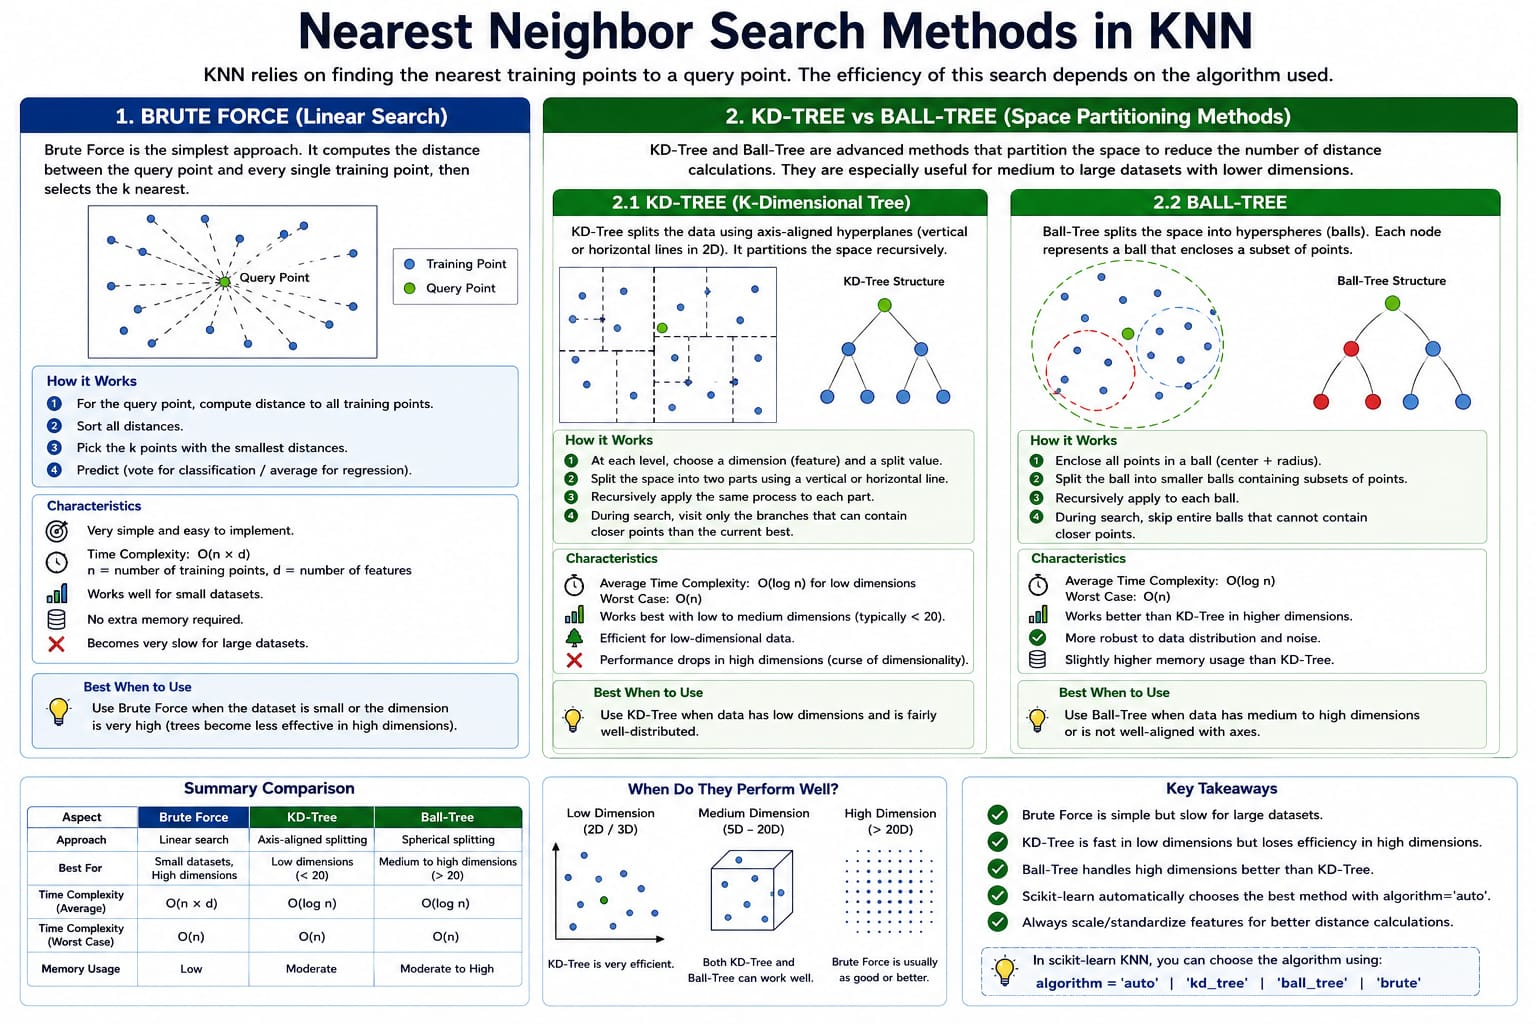

In [8]:
# Import required libraries
import time
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Create a large synthetic classification dataset
X_big, y_big = make_classification(
    n_samples=20000,     # Total number of samples
    n_features=10,       # Number of input features
    random_state=15      # Ensures reproducible results
)

# Split the dataset into training and testing sets
X_big_train, X_big_test, y_big_train, y_big_test = train_test_split(
    X_big,
    y_big,
    test_size=0.20,      # 20% data for testing
    random_state=15
)

# Create an empty list to store prediction times
timing_results = []

# Compare different nearest-neighbor search algorithms
for algorithm in ['brute', 'kd_tree', 'ball_tree']:

    # Create a KNN Classifier using the current search algorithm
    model = KNeighborsClassifier(
        n_neighbors=5,
        algorithm=algorithm
    )

    # Train the model
    model.fit(X_big_train, y_big_train)

    # Record the prediction start time
    start = time.time()

    # Make predictions on the test dataset
    model.predict(X_big_test)

    # Calculate the total prediction time
    elapsed = time.time() - start

    # Store the algorithm name and prediction time
    timing_results.append({
        'algorithm': algorithm,
        'predict_time_sec': elapsed
    })

# Convert the results into a DataFrame
timing_df = pd.DataFrame(timing_results)

# Display the prediction time comparison
timing_df

,algorithm,predict_time_sec
0,brute,0.446675
1,kd_tree,0.424280
2,ball_tree,0.894635


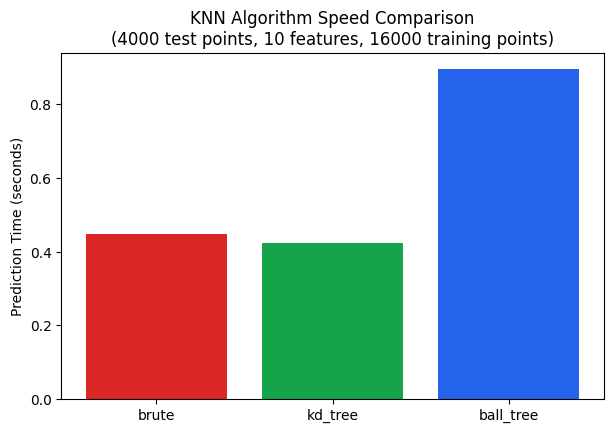

In [9]:
plt.figure(figsize=(7, 4.5))
plt.bar(timing_df['algorithm'], timing_df['predict_time_sec'], color=['#dc2626', '#16a34a', '#2563eb'])
plt.ylabel('Prediction Time (seconds)')
plt.title(f'KNN Algorithm Speed Comparison\n({len(X_big_test)} test points, {X_big_train.shape[1]} features, {len(X_big_train)} training points)')
plt.show()




> On **small or low-dimensional datasets**, the performance difference between the search algorithms is often minimal. In some cases, **`brute`** may even be faster because **KD-Tree** and **Ball-Tree** require additional time to build their tree structures before searching. However, as the dataset becomes larger, **`kd_tree`** and **`ball_tree`** generally provide much faster nearest-neighbor searches by reducing the number of distance calculations. This is why **`algorithm='auto'`** is the default in Scikit-learn—it automatically selects the most appropriate search algorithm based on the size and characteristics of your dataset, helping achieve the best balance between speed and efficiency.
